# Множественная линейная регрессия на чистых данных

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

x = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_x.csv", header=None)
y = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_y.csv", header=None)
print(x.shape, y.shape)
print(x.columns)

(387, 5) (387, 1)
Index([0, 1, 2, 3, 4], dtype='int64')


#### 1. Самостоятельно постройте парные регрессии от каждого атрибута с целевой переменной.

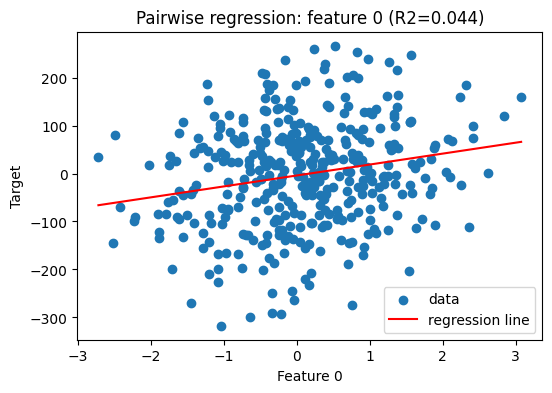

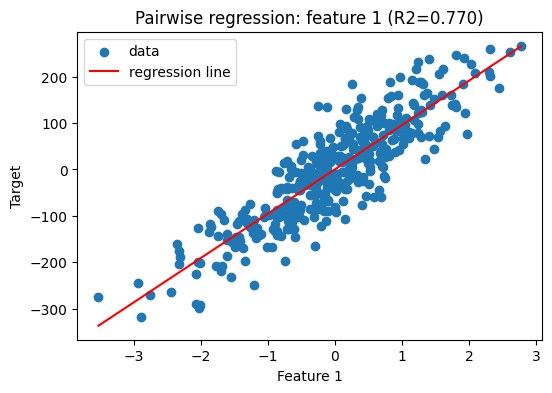

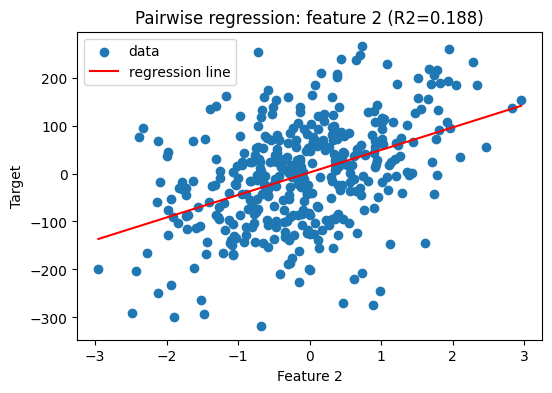

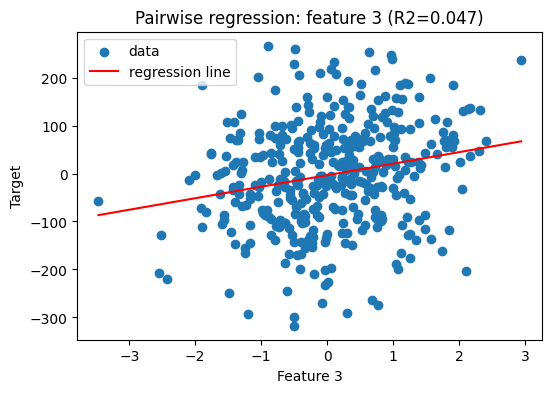

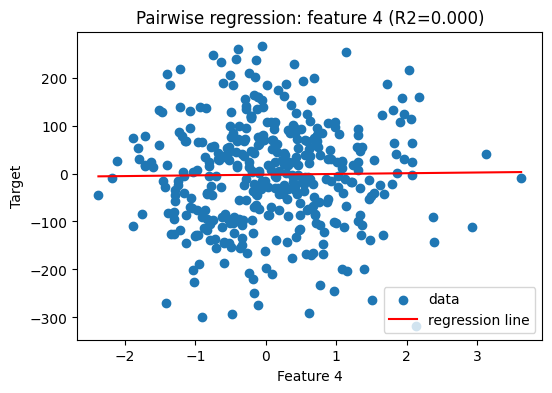

In [38]:
pairwise_models = []
for col in x.columns:
    lr = LinearRegression()
    lr.fit(x[[col]], y)
    pred = lr.predict(x[[col]])
    r2 = lr.score(x[[col]], y)
    coef = lr.coef_[0][0]
    intercept = lr.intercept_[0]
    
    pairwise_models.append({
        "feature": col,
        "intercept": intercept,
        "coefficient": coef,
        "r2_score": r2
    })
    
    plt.figure(figsize=(6,4))
    plt.scatter(x[col], y, label="data")
    xx = np.linspace(x[col].min(), x[col].max(), 100).reshape(-1,1)
    plt.plot(xx, lr.predict(xx), color='red', label='regression line')
    plt.xlabel(f"Feature {col}")
    plt.ylabel("Target")
    plt.title(f"Pairwise regression: feature {col} (R2={r2:.3f})")
    plt.legend()
    plt.show()

#### 2. Модифицируйте код из предыдущей работы так, чтобы модель регрессии умела работать с входными данными, состоящими из произвольного количества столбцов.

In [ ]:
class MultiLinearModel:
    def __init__(self):
        self.model = LinearRegression() # can already work with any amount of columns
    
    def fit(self, X, Y):
        self.model.fit(X, Y)
    
    def predict(self, X):
        return self.model.predict(X)
    
    def score(self, X, Y):
        return self.model.score(X, Y)
    
    def coef(self):
        return self.model.coef
    
    def intercept(self):
        return self.model.intercept

#### 3. Для целевой переменной и каждого из признаков постройте полиномиальную регрессию второго, третьего и десятого порядков. Сделайте вывод о значимости регрессии.


 polynomial regression 0:


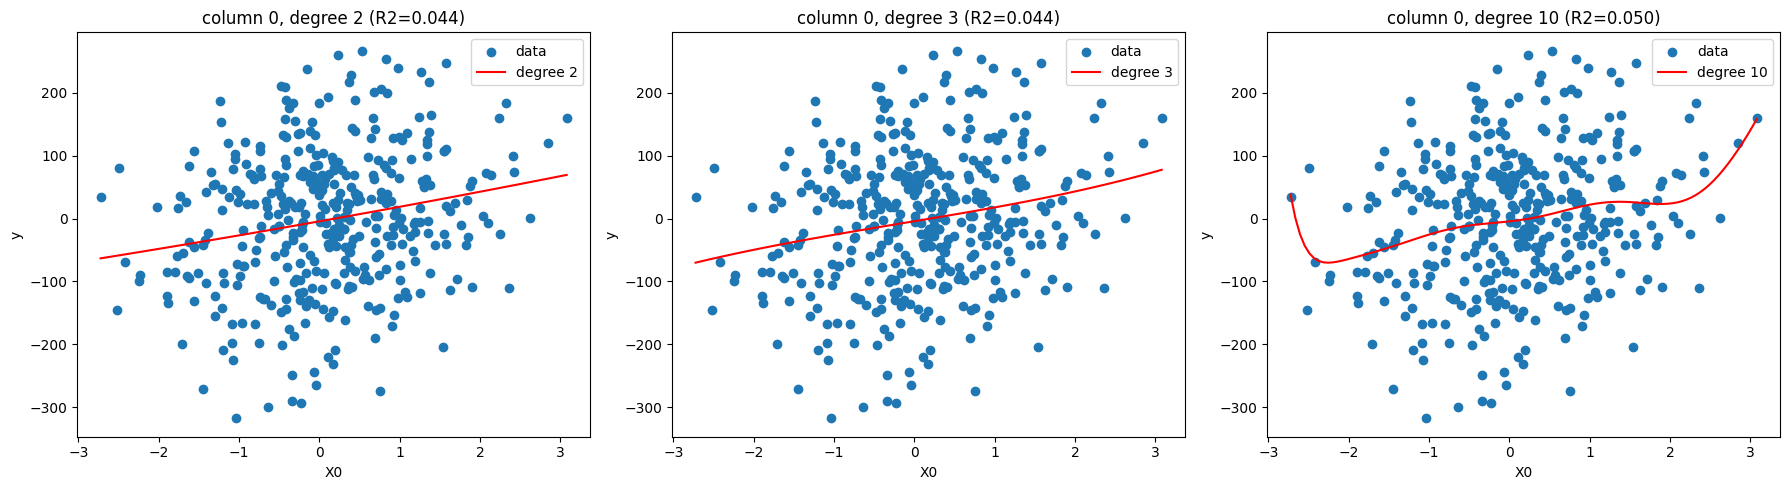


 polynomial regression 1:


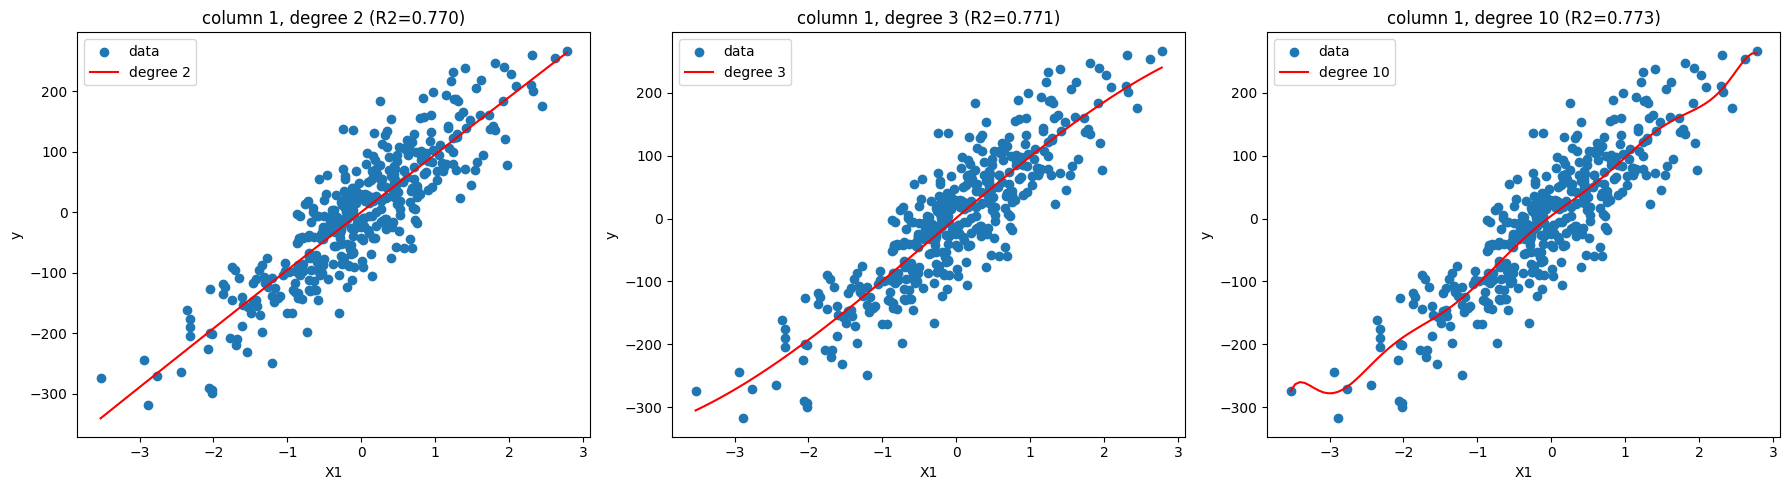


 polynomial regression 2:


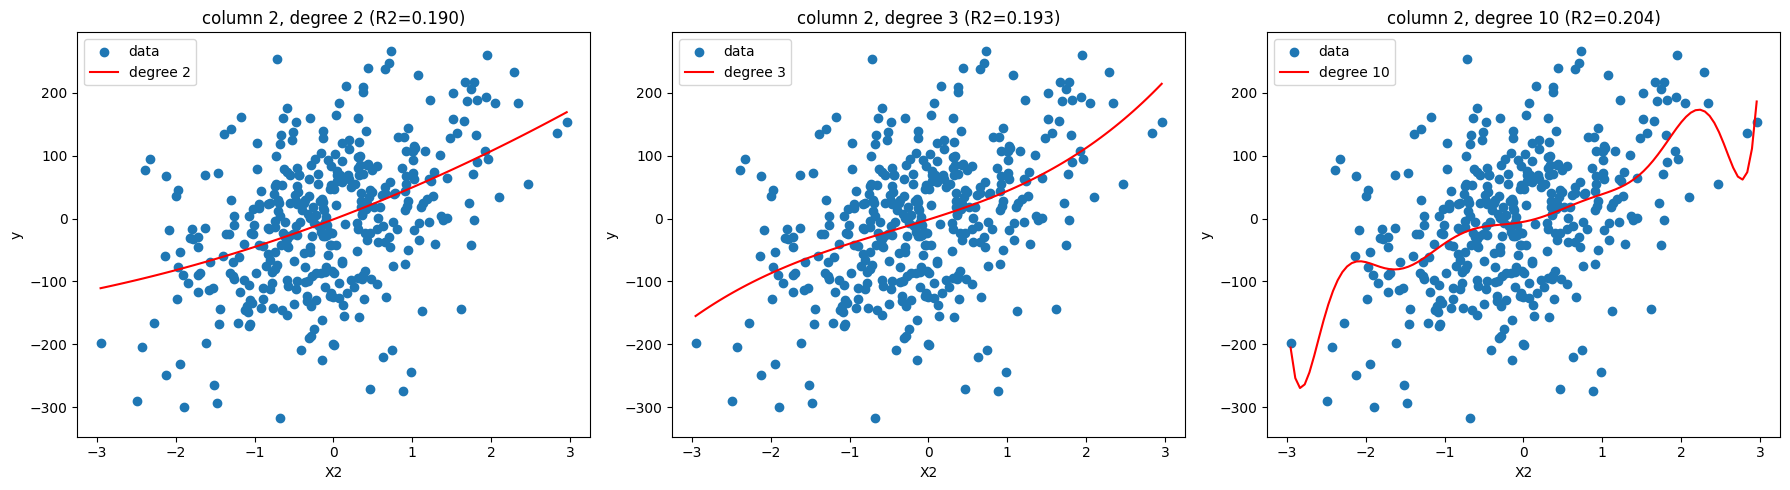


 polynomial regression 3:


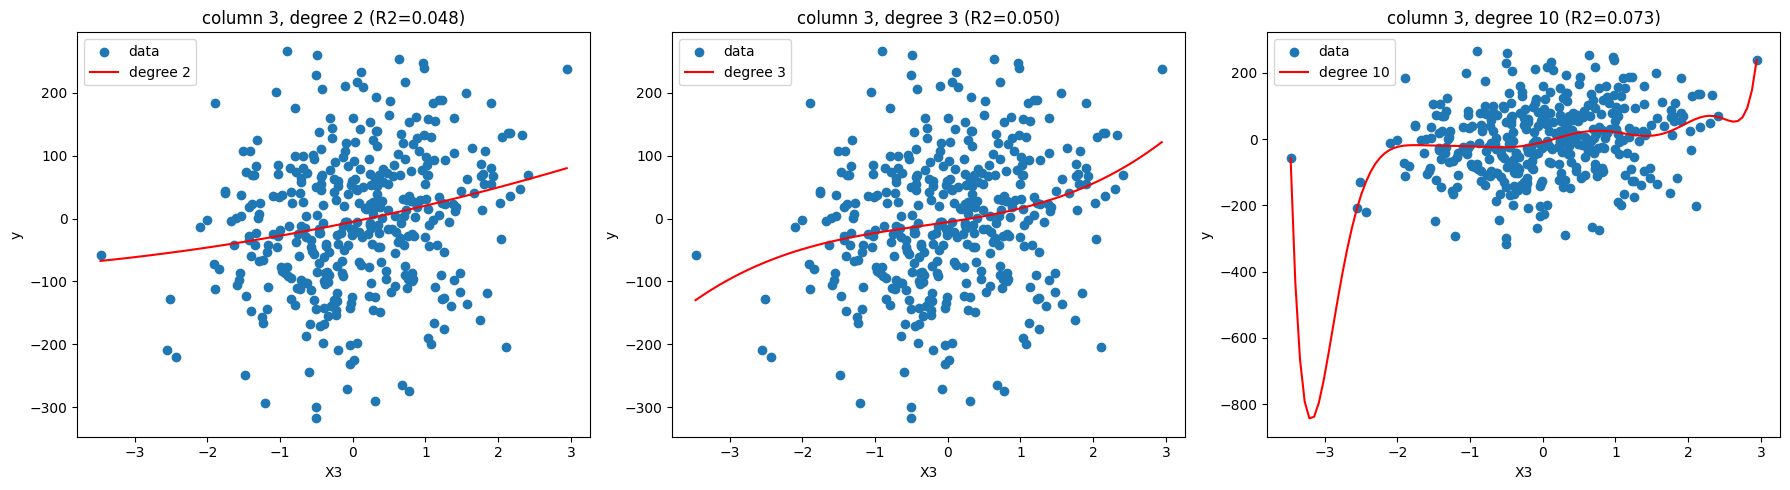


 polynomial regression 4:


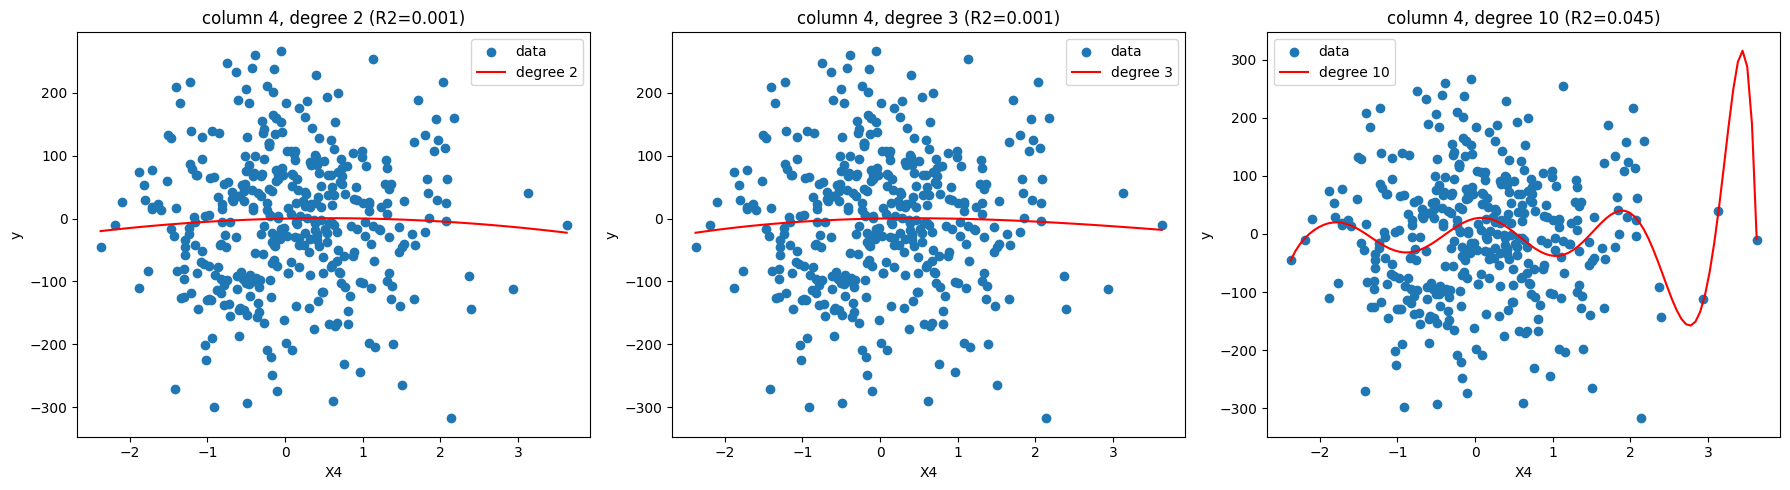

In [53]:
poly_orders = [2, 3, 10]
poly_results = []

for col in x.columns:
    X_col = x[[col]]
    Y_col = y
    print(f"\n polynomial regression {col}:")
    plt.figure(figsize=(18, 5))

    for i, order in enumerate(poly_orders, start=1):
        poly = PolynomialFeatures(degree=order)
        X_poly = poly.fit_transform(X_col)
        lr = LinearRegression()
        start_time = time.time()
        lr.fit(X_poly, Y_col)
        duration = time.time() - start_time
        pred = lr.predict(X_poly)
        r2 = r2_score(Y_col, pred)
        mse = mean_squared_error(Y_col, pred)
        poly_results.append({
            "feature": col,
            "order": order,
            "r2_score": r2,
            "mse": mse,
            "time": duration
        })

        xx = np.linspace(X_col.min(), X_col.max(), 100).reshape(-1,1)
        xx_poly = poly.transform(xx)
        yy = lr.predict(xx_poly)

        plt.subplot(1, 3, i)
        plt.scatter(X_col, Y_col, label="data")
        plt.plot(xx, yy, color='red', label=f"degree {order}")
        plt.title(f"column {col}, degree {order} (R2={r2:.3f})")
        plt.xlabel(f"X{col}")
        plt.ylabel("y")
        plt.legend()

    plt.tight_layout()
    plt.show()

#### 4. Постройте сводную таблицу показателей точности всех построенных моделей. Сделайте вывод, какие модели переобученнные, какие - недообученные.

In [55]:
poly_df = pd.DataFrame(poly_results)
poly_df

,feature,order,r2_score,mse,time
0,0,2,0.043672,11491.909255,0.001013
1,0,3,0.043765,11490.787323,0.001007
2,0,10,0.050356,11411.586520,0.001002
3,1,2,0.769994,2763.909753,0.001554
4,1,3,0.771118,2750.401156,0.001001
5,1,10,0.772677,2731.672893,0.001000
6,2,2,0.190008,9733.431563,0.001002
7,2,3,0.192802,9699.859735,0.001001
8,2,10,0.204409,9560.372197,0.001001
9,3,2,0.047943,11440.588266,0.001001


#### 5. Используйте другие метрики качества регрессионной модели в дополнение к коэффициенту детерминации.

In [42]:
poly_df['mae'] = poly_df.apply(lambda row: mean_absolute_error(
    y, 
    LinearRegression().fit(
        PolynomialFeatures(degree=row['order']).fit_transform(x[[row['feature']]]), y
    ).predict(PolynomialFeatures(degree=row['order']).fit_transform(x[[row['feature']]]))
), axis=1)

poly_df

InvalidParameterError: The 'degree' parameter of PolynomialFeatures must be an int in the range [0, inf) or an array-like. Got np.float64(2.0) instead.

#### 6. Замерьте время обучения полиномиальных моделей с разной степенью полинома. Сделайте вывод.

In [ ]:
print(duration)

0.0010037422180175781
